# EDA 002.01 — NFL Play by Play 2009

**Kaggle NFL Data Analysis**

This notebook analyzes NFL play-by-play data from multiple seasons (2009-2016, 2009-2017, 2009-2018).

**Dataset:** The dataset for this exercise can be downloaded from https://www.kaggle.com/code/alexisbcook/handling-missing-values

In [37]:
import zipfile
from pathlib import Path

import pandas as pd

from libs.eda import display_missing, plot_missing_bars, plot_missing_heatmap

## Step 1: Extract Kaggle ZIP Files

In [38]:
# Set the kaggle directory path
kaggle_dir = Path("kaggle")
print(f"kaggle directory: {kaggle_dir.resolve()}")

kaggle directory: /home/sandeep/workspace/learn-ml/ml-201/kaggle


In [39]:
# List all zip files in the kaggle directory
zip_files = list(kaggle_dir.glob("*.zip"))
print(f"Found {len(zip_files)} ZIP file(s):\n")
for zf in sorted(zip_files):
    print(f"  - {zf.name}")

Found 3 ZIP file(s):

  - NFL Play by Play 2009-2016 (v3).csv.zip
  - NFL Play by Play 2009-2017 (v4).csv.zip
  - NFL Play by Play 2009-2018 (v5).csv.zip


In [40]:
def extract_zip_file(zip_path, extract_to=None):
    """Extract a single ZIP file.
    
    Parameters
    ----------
    zip_path : str or Path
        Path to the ZIP file.
    extract_to : str or Path, optional
        Directory to extract to. If None, extracts to the parent directory of the ZIP file.
        
    Returns
    -------
    Path
        The directory where files were extracted.
    """
    zip_path = Path(zip_path)
    if extract_to is None:
        extract_to = zip_path.parent
    else:
        extract_to = Path(extract_to)
    
    extract_to.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    
    return extract_to


# Example: extract a single ZIP file
example_zip = zip_files[0]
print(f"Extracting {example_zip.name}...")
extract_dir = extract_zip_file(example_zip)
print(f"✓ Extracted to: {extract_dir}")
print(f"✓ Contents: {list(extract_dir.glob('*'))[:3]}...")  # Show first 3 items

Extracting NFL Play by Play 2009-2016 (v3).csv.zip...
✓ Extracted to: kaggle
✓ Contents: [PosixPath('kaggle/.gitignore'), PosixPath('kaggle/NFL Play by Play 2009-2016 (v3).csv.zip'), PosixPath('kaggle/NFL Play by Play 2009-2018 (v5).csv.zip')]...


In [41]:
def extract_all_zips_in_directory(directory, extract_to=None):
    """Walk a directory and extract all ZIP files.
    
    Parameters
    ----------
    directory : str or Path
        Directory to search for ZIP files (recursively).
    extract_to : str or Path, optional
        Directory to extract files to. If None, extracts in place (each ZIP in its own parent dir).
        
    Returns
    -------
    dict
        Mapping of ZIP file paths to extraction status and result.
    """
    directory = Path(directory)
    results = {}
    
    # Find all ZIP files recursively
    for zip_path in directory.rglob("*.zip"):
        try:
            dest = Path(extract_to) if extract_to else zip_path.parent
            extract_zip_file(zip_path, extract_to=dest)
            results[str(zip_path)] = {
                "status": "✓ extracted",
                "extracted_to": str(dest),
            }
        except Exception as e:
            results[str(zip_path)] = {
                "status": "✗ failed",
                "error": str(e),
            }
    
    return results


# Extract ALL ZIP files in the kaggle directory
print("Extracting ALL ZIP files in the kaggle directory...\n")
extraction_results = extract_all_zips_in_directory(kaggle_dir)

for zip_file, result in extraction_results.items():
    print(f"{result['status']} — {Path(zip_file).name}")
    if result['status'].startswith("✓"):
        print(f"  → {result['extracted_to']}")
    else:
        print(f"  → Error: {result.get('error', 'Unknown error')}")
    print()

Extracting ALL ZIP files in the kaggle directory...

✓ extracted — NFL Play by Play 2009-2016 (v3).csv.zip
  → kaggle

✓ extracted — NFL Play by Play 2009-2018 (v5).csv.zip
  → kaggle

✓ extracted — NFL Play by Play 2009-2017 (v4).csv.zip
  → kaggle



In [42]:
# Verify extraction — list all CSV files in kaggle directory
csv_files = list(kaggle_dir.rglob("*.csv"))
print(f"Found {len(csv_files)} CSV file(s) after extraction:\n")
for csv in sorted(csv_files):
    size_mb = csv.stat().st_size / (1024 * 1024)
    print(f"  - {csv.relative_to(kaggle_dir)} ({size_mb:.1f} MB)")

Found 3 CSV file(s) after extraction:

  - NFL Play by Play 2009-2016 (v3).csv (233.7 MB)
  - NFL Play by Play 2009-2017 (v4).csv (262.8 MB)
  - NFL Play by Play 2009-2018 (v5).csv (668.0 MB)


## Step 2: Process CSV Files

In [43]:
def process_csv(csv_path):
    """Load a CSV file and display its missing value summary.
    
    Parameters
    ----------
    csv_path : str or Path
        Path to the CSV file.
    """
    csv_path = Path(csv_path)
    print(f"\n{'='*70}")
    print(f"Processing: {csv_path.name}")
    print(f"{'='*70}\n")
    
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Display basic info
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}\n")
    
    # Visualize missing values
    plot_missing_bars(df)
    plot_missing_heatmap(df)
    
    # Display missing values summary
    missing_summary = display_missing(df)
    if missing_summary.empty:
        print("✓ No missing values found!\n")
    else:
        print("\nMissing Value Summary:")
        print(missing_summary)

Found 3 CSV file(s)


Processing: NFL Play by Play 2009-2016 (v3).csv



/tmp/ipykernel_11031/2745782608.py:15: DtypeWarning: Columns (25,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Shape: (362447, 102)
Columns: ['Date', 'GameID', 'Drive', 'qtr', 'down', 'time', 'TimeUnder', 'TimeSecs', 'PlayTimeDiff', 'SideofField', 'yrdln', 'yrdline100', 'ydstogo', 'ydsnet', 'GoalToGo', 'FirstDown', 'posteam', 'DefensiveTeam', 'desc', 'PlayAttempted', 'Yards.Gained', 'sp', 'Touchdown', 'ExPointResult', 'TwoPointConv', 'DefTwoPoint', 'Safety', 'Onsidekick', 'PuntResult', 'PlayType', 'Passer', 'Passer_ID', 'PassAttempt', 'PassOutcome', 'PassLength', 'AirYards', 'YardsAfterCatch', 'QBHit', 'PassLocation', 'InterceptionThrown', 'Interceptor', 'Rusher', 'Rusher_ID', 'RushAttempt', 'RunLocation', 'RunGap', 'Receiver', 'Receiver_ID', 'Reception', 'ReturnResult', 'Returner', 'BlockingPlayer', 'Tackler1', 'Tackler2', 'FieldGoalResult', 'FieldGoalDistance', 'Fumble', 'RecFumbTeam', 'RecFumbPlayer', 'Sack', 'Challenge.Replay', 'ChalReplayResult', 'Accepted.Penalty', 'PenalizedTeam', 'PenaltyType', 'PenalizedPlayer', 'Penalty.Yards', 'PosTeamScore', 'DefTeamScore', 'ScoreDiff', 'AbsScoreDif

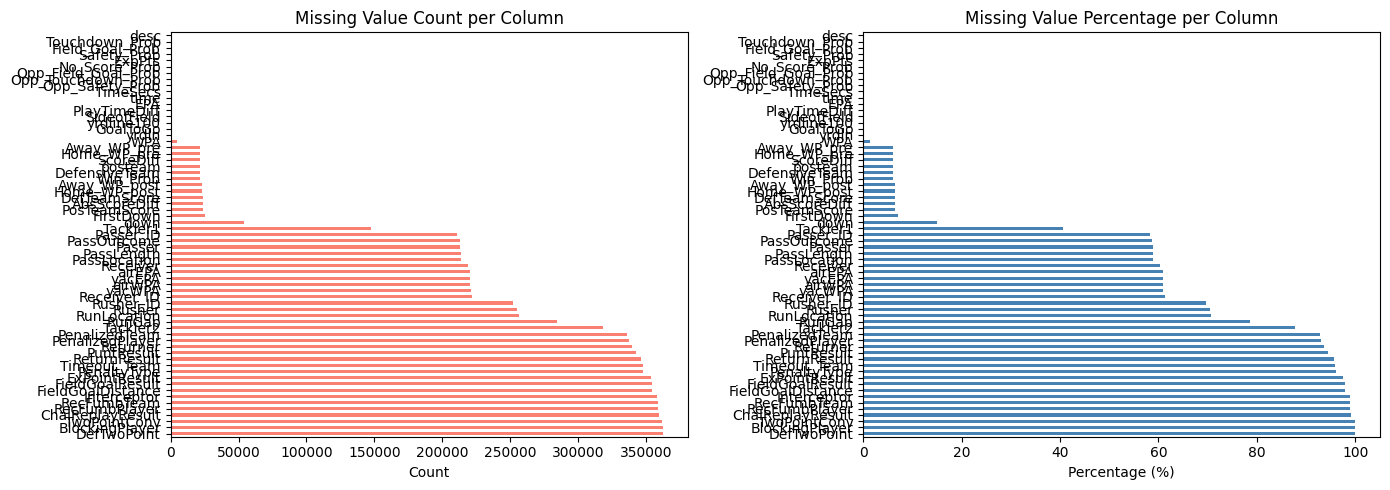

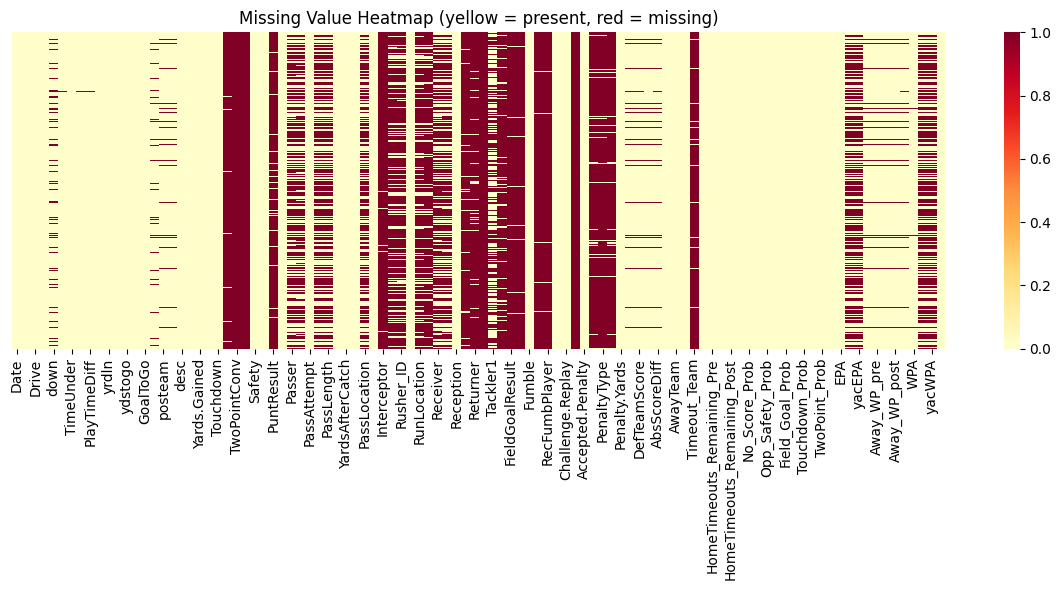


Missing Value Summary:
                  missing_count missing_percent
DefTwoPoint              362433          100.0%
BlockingPlayer           362341          99.97%
TwoPointConv             361919          99.85%
ChalReplayResult         359476          99.18%
RecFumbPlayer            358513          98.91%
...                         ...             ...
ExpPts                      148           0.04%
Safety_Prob                 148           0.04%
Field_Goal_Prob             148           0.04%
Touchdown_Prob              148           0.04%
desc                          2            0.0%

[65 rows x 2 columns]

Processing: NFL Play by Play 2009-2017 (v4).csv



/tmp/ipykernel_11031/2745782608.py:15: DtypeWarning: Columns (25,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Shape: (407688, 102)
Columns: ['Date', 'GameID', 'Drive', 'qtr', 'down', 'time', 'TimeUnder', 'TimeSecs', 'PlayTimeDiff', 'SideofField', 'yrdln', 'yrdline100', 'ydstogo', 'ydsnet', 'GoalToGo', 'FirstDown', 'posteam', 'DefensiveTeam', 'desc', 'PlayAttempted', 'Yards.Gained', 'sp', 'Touchdown', 'ExPointResult', 'TwoPointConv', 'DefTwoPoint', 'Safety', 'Onsidekick', 'PuntResult', 'PlayType', 'Passer', 'Passer_ID', 'PassAttempt', 'PassOutcome', 'PassLength', 'AirYards', 'YardsAfterCatch', 'QBHit', 'PassLocation', 'InterceptionThrown', 'Interceptor', 'Rusher', 'Rusher_ID', 'RushAttempt', 'RunLocation', 'RunGap', 'Receiver', 'Receiver_ID', 'Reception', 'ReturnResult', 'Returner', 'BlockingPlayer', 'Tackler1', 'Tackler2', 'FieldGoalResult', 'FieldGoalDistance', 'Fumble', 'RecFumbTeam', 'RecFumbPlayer', 'Sack', 'Challenge.Replay', 'ChalReplayResult', 'Accepted.Penalty', 'PenalizedTeam', 'PenaltyType', 'PenalizedPlayer', 'Penalty.Yards', 'PosTeamScore', 'DefTeamScore', 'ScoreDiff', 'AbsScoreDif

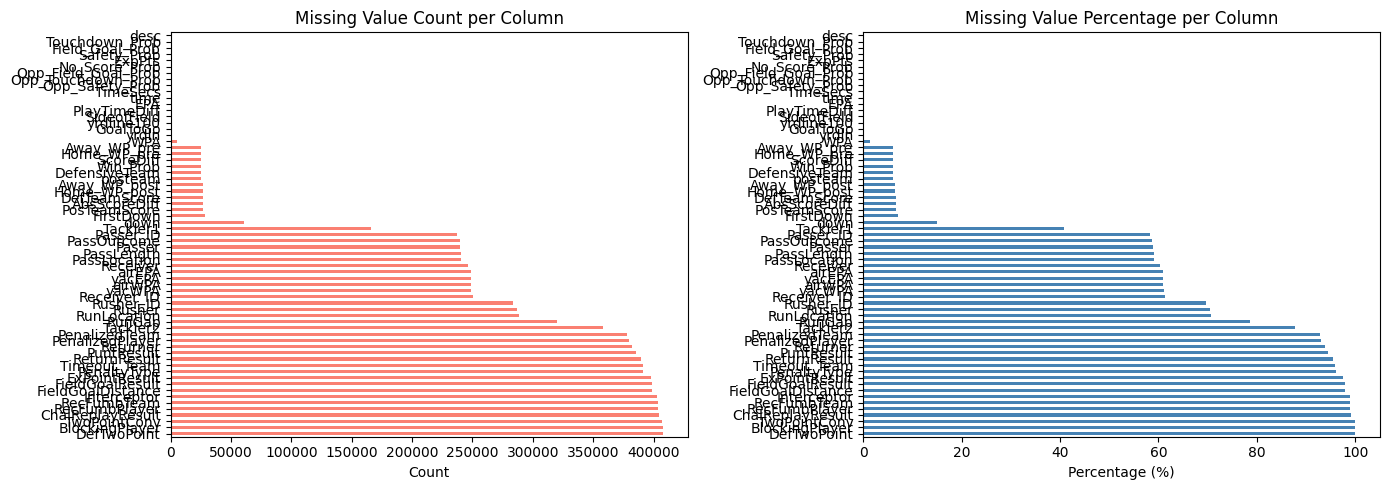

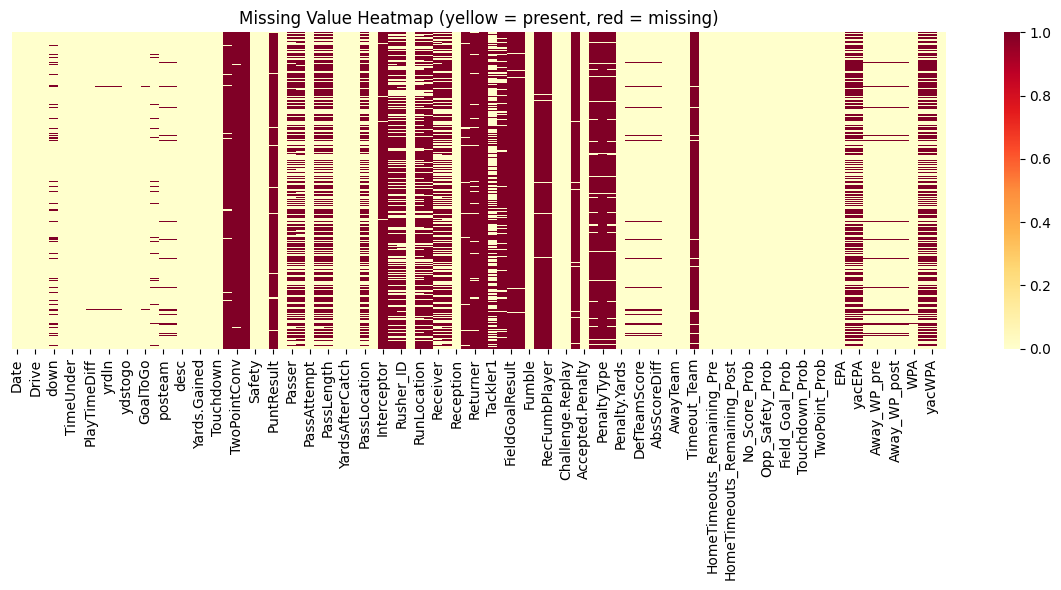


Missing Value Summary:
                  missing_count missing_percent
DefTwoPoint              407664          99.99%
BlockingPlayer           407571          99.97%
TwoPointConv             407083          99.85%
ChalReplayResult         404286          99.17%
RecFumbPlayer            403315          98.93%
...                         ...             ...
ExpPts                      176           0.04%
Safety_Prob                 176           0.04%
Field_Goal_Prob             176           0.04%
Touchdown_Prob              176           0.04%
desc                          2            0.0%

[65 rows x 2 columns]

Processing: NFL Play by Play 2009-2018 (v5).csv



/tmp/ipykernel_11031/2745782608.py:15: DtypeWarning: Columns (42,166,167,168,169,174,175,178,179,182,183,188,189,190,191,194,195,203,204,205,218,219,220,231,232,233,238,240,241,249) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Shape: (449371, 255)
Columns: ['play_id', 'game_id', 'home_team', 'away_team', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'pass_length', 'pass_location', 'air_yards', 'yards_after_catch', 'run_location', 'run_gap', 'field_goal_result', 'kick_distance', 'extra_point_result', 'two_point_conv_result', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'timeout_team', 'td_team', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post', 'defteam_score_post', 'score_differential_post', 'no_score_prob', 'opp_fg_prob', 'o

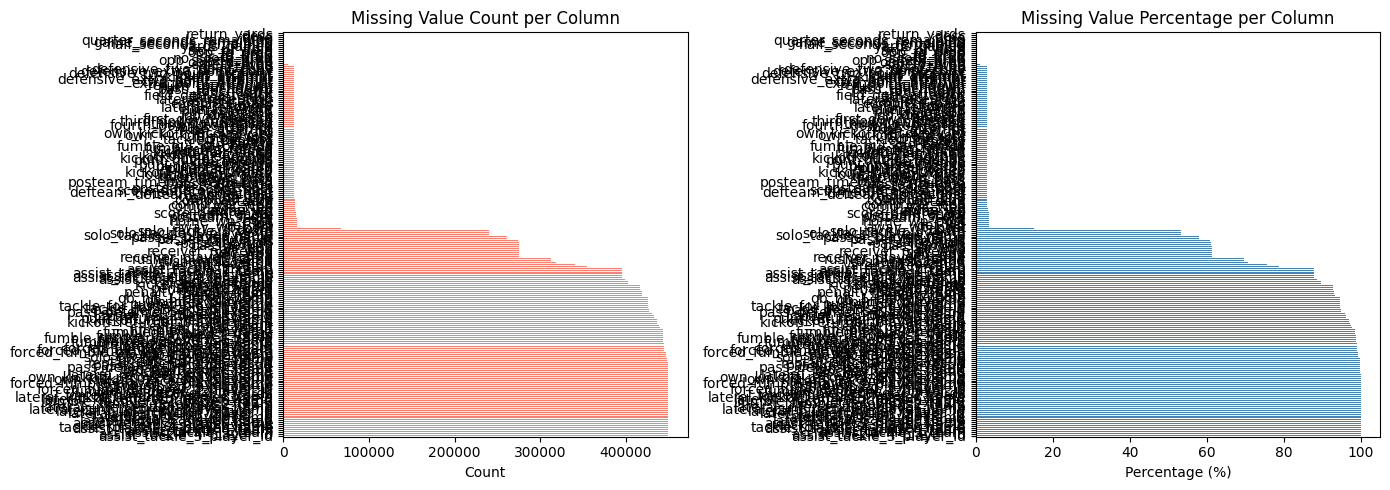

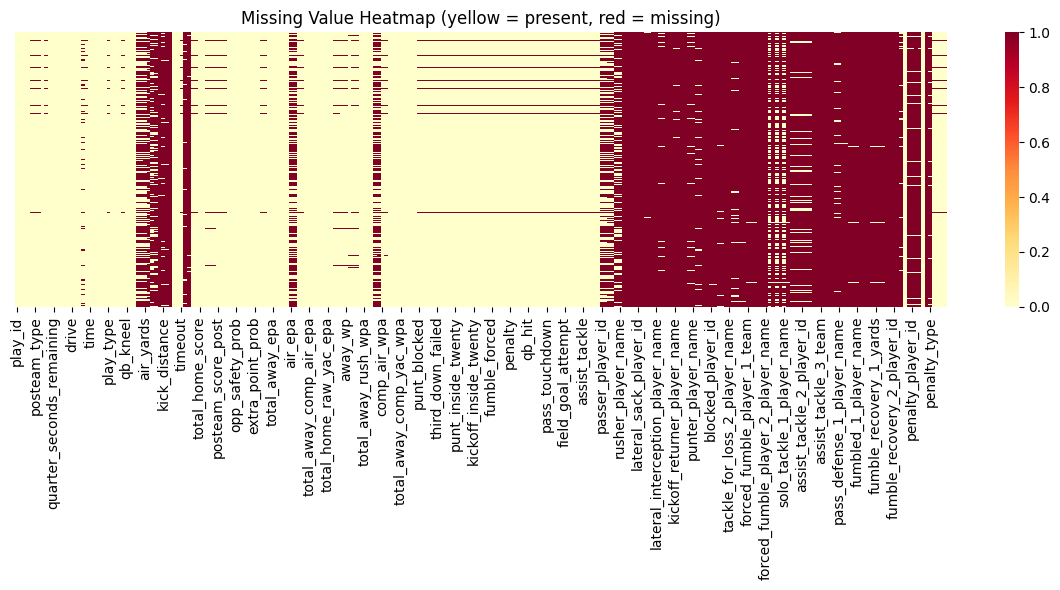


Missing Value Summary:
                             missing_count missing_percent
assist_tackle_3_player_id           449368          100.0%
assist_tackle_4_player_id           449371          100.0%
assist_tackle_3_team                449368          100.0%
assist_tackle_4_team                449371          100.0%
assist_tackle_4_player_name         449371          100.0%
...                                    ...             ...
game_seconds_remaining                 163           0.04%
quarter_seconds_remaining              141           0.03%
time                                   141           0.03%
desc                                     2            0.0%
return_yards                            21            0.0%

[205 rows x 2 columns]

Processed 3 CSV file(s)



In [44]:
# Process all CSV files in the kaggle directory
csv_files = sorted(list(kaggle_dir.rglob("*.csv")))
print(f"Found {len(csv_files)} CSV file(s)\n")

for csv_file in csv_files:
    process_csv(csv_file)

print(f"\n{'='*70}")
print(f"Processed {len(csv_files)} CSV file(s)")
print(f"{'='*70}\n")